# 03 CNN Advanced Architectures

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a small **residual-style** block (skip connection) with the Keras **Functional API**
- Train it briefly on an MNIST subset to confirm the wiring runs end to end
- Understand (in theory) why residual connections let us train very deep CNNs — at this tiny 1-block scale the benefit is not measurable, so we don't pretend to demonstrate it

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 2, lesson 04 "Programming Backpropagation in Neural Networks" — a skip connection exists to stop the backward gradient from vanishing through many layers.

---

## 🌍 Real life

**📌 Real case — the plot that proved more layers stop helping.** Figure 1 of the ResNet paper (He, Zhang, Ren & Sun, CVPR 2016) is a CIFAR-10 chart in which a **56-layer plain network has higher *training* error than a 20-layer one**. Not worse generalisation — worse fitting. The deeper network could not even learn the data it was shown, and no amount of regularisation addresses that, because it is an optimisation failure, not overfitting. Adding the skip connection you are about to build removed the problem: the same team's 152-layer residual ensemble reached **3.57% error on the ImageNet test set** and first place in ILSVRC-2015.

**⚡ Why this matters — what goes wrong without it.** "More layers stop helping" is not a proverb; it is a measured curve. Past roughly twenty plain layers, each extra layer made training *worse*, because the gradient had to survive a longer product of derivatives to reach the front of the network. `Add([x, shortcut])` gives that gradient a path that skips the convolutions entirely. It is one line of code, and it is the reason depth became usable at all.

**Where is this used?** ResNet, VGG, Inception are used in **image classification**, **object detection**, and **segmentation** in industry and research.

**In this notebook we use** a **residual block** (conv + skip connection) so the network can learn **residuals** instead of full mappings. We use **skip connections** (instead of a plain deep stack of conv layers) **because** they help gradients flow and allow training **deeper** networks without vanishing gradients.

**📌 Covers slide(s):** **16** — CNN Architectures (LeNet, AlexNet). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **ResNet (residual network):** Each block computes F(x) and outputs **x + F(x)** (skip connection). The network learns **residuals** (what to add) instead of the full mapping.
- **Why residuals?** Very deep plain networks can suffer from vanishing gradients; skip connections give a direct path for gradients and make optimization easier.
- **VGG / Inception:** VGG = many small 3×3 convs; Inception = multiple filter sizes in parallel. We focus on the residual idea here.
- **We use a residual block** instead of only conv layers so we can go deeper without losing gradient flow.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, MNIST (small subset). We build a tiny model with one residual block.

**Dataset:** Real — MNIST (small subset).

**Outputs:** Model summary showing residual block structure; optional short training to show it runs.

## Step 1: Imports

In [1]:
# WHAT: import NumPy and TensorFlow/Keras with a guarded import.
# WHY: a broken TensorFlow install should produce a repair hint, not a page of tracebacks.
import numpy as np

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

print("TensorFlow:", "yes" if HAS_TF else "no")

TensorFlow: yes


### New tool: the Keras Functional API

So far every Keras model was `keras.Sequential([...])` — a straight stack of layers. A skip connection **cannot** be expressed as a stack: the input must branch, flow through two conv layers, and merge back with `Add()`. The **Functional API** handles such graphs:

```python
inp = keras.Input(shape=(28, 28, 1))   # 1. declare the input
x = keras.layers.Conv2D(32, (3, 3))(inp)  # 2. call layers like functions
model = keras.Model(inp, x)            # 3. wrap input+output into a Model
```

Any layer output can feed any number of later layers — that freedom is what lets us wire the `Add([x, shortcut])` merge below. You will meet this pattern again in `04`, unit 3 (attention models) and unit 4 (autoencoders/GANs).


## Step 2: Define a residual block (we use skip connection so gradients flow and we can train deeper nets)

In [2]:
# WHAT: build a mini ResNet - a conv layer, one residual block, then global pooling and softmax.
# WHY: the Add([x, shortcut]) skip connection is THE idea that let networks grow past ~20 layers.
if HAS_TF:
    # A residual block: two convs, then add the original input back (the 'shortcut') before the final ReLU.
    def residual_block(x, filters):
        shortcut = x
        x = keras.layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
        x = keras.layers.Conv2D(filters, (3, 3), padding="same")(x)
        x = keras.layers.Add()([x, shortcut])
        x = keras.layers.Activation("relu")(x)
        return x

    # Assemble with the Functional API: input -> conv -> residual block -> pooled features -> 10 classes.
    inp = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
    x = residual_block(x, 32)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inp, x)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()
    print("\nResidual block: conv → conv → Add(shortcut) → ReLU. Skip connection helps gradient flow.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_2[0][0],   │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │        330 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,146 (74.79 KB)

 Trainable params: 19,146 (74.79 KB)

 Non-trainable params: 0 (0.00 B)


Residual block: conv → conv → Add(shortcut) → ReLU. Skip connection helps gradient flow.


## Step 3: Train on MNIST subset (2 epochs to verify it runs)

In [3]:
# WHAT: train the mini ResNet briefly on MNIST and report validation accuracy.
# WHY: even 2 epochs shows the architecture learns; skip connections keep gradients flowing.
if HAS_TF:
    # Standard MNIST prep: scale to 0-1, add the channel axis, keep 5,000 samples for speed.
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train[..., np.newaxis][:5000]
    y_train = y_train[:5000]
    x_test = x_test[..., np.newaxis]
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=128, verbose=1)
    print("Final val accuracy: %.4f" % history.history["val_accuracy"][-1])

Epoch 1/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - accuracy: 0.0859 - loss: 2.3124

 3/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.0938 - loss: 2.3033  

 5/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1047 - loss: 2.3000

 7/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1161 - loss: 2.2972

...

35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1208 - loss: 2.2571

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1239 - loss: 2.2546

39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1266 - loss: 2.2529

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.1270 - loss: 2.2526 - val_accuracy: 0.1822 - val_loss: 2.1857


Final val accuracy: 0.1822


## Step 4: Measure what the skip connection actually does

The objectives above are honest that **one** residual block cannot show you the benefit. But there is something this notebook *can* measure in a couple of seconds, and it is the mechanism itself rather than the accuracy: build a **20-layer** stack twice — once plain, once with `Add([x, shortcut])` every two layers, from the same initial weights — push one batch of real MNIST images through, and look at what survives.

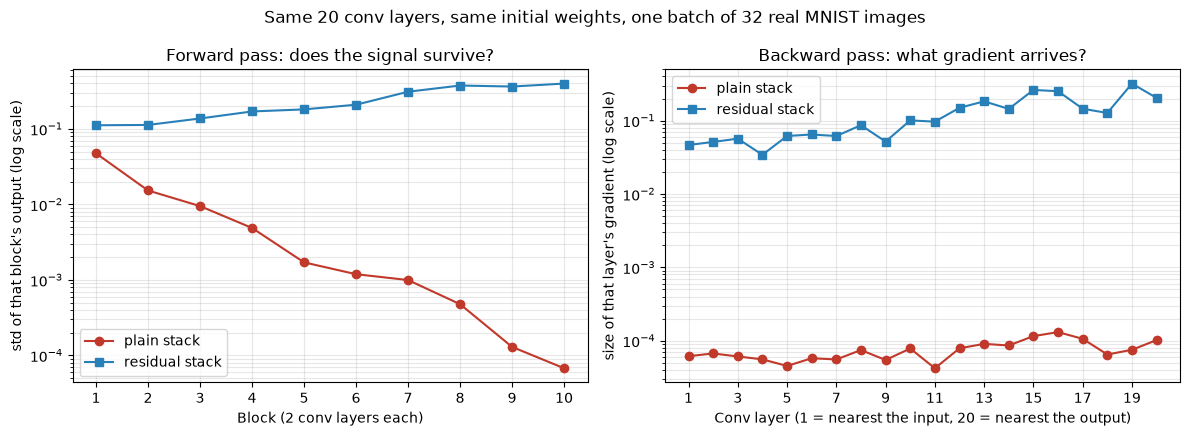

PLAIN    : block-1 output std 4.75e-02  ->  block-10 output std 6.76e-05   (shrinks 703x)
RESIDUAL : block-1 output std 1.12e-01  ->  block-10 output std 3.99e-01   (changes 3.6x)
Median gradient size, residual / plain, over all 20 conv layers: 1367x
Loss on this batch: plain 2.3026, residual 2.2834  (ln 10 = 2.3026 is the no-information value)


In [4]:
# WHAT: build a 20-conv-layer stack twice (plain vs residual, identical init), run ONE forward and
#       ONE backward pass on 32 real MNIST images, and record activation scale + gradient size.
# WHY: this measures the MECHANISM (does signal reach the top, does gradient reach the bottom),
#      which is cheap - unlike the accuracy comparison, which needs GPU-hours.
if HAS_TF:
    import matplotlib.pyplot as plt

    xb = (x_train[:32]).astype(np.float32)      # 32 real MNIST images, already scaled to [0, 1]
    yb = y_train[:32]
    DEPTH, F = 20, 16                            # 20 conv layers, 16 filters each - small but deep

    def build_stack(residual, seed=0):
        """Same 20 conv layers either way; `residual` only decides whether Add(shortcut) is used."""
        keras.utils.set_random_seed(seed)        # identical initial weights for both stacks
        inp = keras.Input(shape=(28, 28, 1))
        x = keras.layers.Conv2D(F, (3, 3), padding="same", activation="relu")(inp)
        convs, taps = [], []
        for _ in range(DEPTH // 2):
            shortcut = x
            c1 = keras.layers.Conv2D(F, (3, 3), padding="same", activation="relu")
            c2 = keras.layers.Conv2D(F, (3, 3), padding="same")
            x = c1(x); x = c2(x); convs += [c1, c2]
            if residual:
                x = keras.layers.Add()([x, shortcut])     # <- the one line under test
            x = keras.layers.Activation("relu")(x)
            taps.append(x)                                 # record each block's output
        out = keras.layers.Dense(10, activation="softmax")(
            keras.layers.GlobalAveragePooling2D()(x))
        return keras.Model(inp, out), convs, keras.Model(inp, taps)

    def measure(residual):
        model_m, convs, probe = build_stack(residual)
        with tf.GradientTape() as tape:                    # one forward + one backward pass
            loss = keras.losses.SparseCategoricalCrossentropy()(yb, model_m(xb, training=True))
        grads = tape.gradient(loss, [c.kernel for c in convs])
        acts = probe.predict(xb, verbose=0)
        return ([float(tf.norm(g)) for g in grads],
                [float(np.std(a)) for a in acts], float(loss))

    g_plain, a_plain, l_plain = measure(False)
    g_res,   a_res,   l_res   = measure(True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
    blocks = range(1, len(a_plain) + 1)
    ax1.semilogy(blocks, a_plain, "o-", color="#c0392b", label="plain stack")
    ax1.semilogy(blocks, a_res, "s-", color="#2980b9", label="residual stack")
    ax1.set_xlabel("Block (2 conv layers each)")
    ax1.set_ylabel("std of that block's output (log scale)")
    ax1.set_title("Forward pass: does the signal survive?")
    ax1.set_xticks(list(blocks)); ax1.grid(alpha=0.3, which="both"); ax1.legend()

    layers_x = range(1, len(g_plain) + 1)
    ax2.semilogy(layers_x, g_plain, "o-", color="#c0392b", label="plain stack")
    ax2.semilogy(layers_x, g_res, "s-", color="#2980b9", label="residual stack")
    ax2.set_xlabel("Conv layer (1 = nearest the input, %d = nearest the output)" % DEPTH)
    ax2.set_ylabel("size of that layer's gradient (log scale)")
    ax2.set_title("Backward pass: what gradient arrives?")
    ax2.set_xticks(list(layers_x)[::2]); ax2.grid(alpha=0.3, which="both"); ax2.legend()
    fig.suptitle("Same %d conv layers, same initial weights, one batch of 32 real MNIST images" % DEPTH,
                 fontsize=12)
    plt.tight_layout(); plt.show()

    # Print the numbers the picture is claiming, so text and figure can be checked against each other.
    print("PLAIN    : block-1 output std %.2e  ->  block-%d output std %.2e   (shrinks %.0fx)"
          % (a_plain[0], len(a_plain), a_plain[-1], a_plain[0] / a_plain[-1]))
    print("RESIDUAL : block-1 output std %.2e  ->  block-%d output std %.2e   (changes %.1fx)"
          % (a_res[0], len(a_res), a_res[-1], a_res[-1] / a_res[0]))
    print("Median gradient size, residual / plain, over all %d conv layers: %.0fx"
          % (DEPTH, float(np.median(np.array(g_res) / np.array(g_plain)))))
    print("Loss on this batch: plain %.4f, residual %.4f  (ln 10 = %.4f is the no-information value)"
          % (l_plain, l_res, np.log(10)))

**Read the figure.** Left panel — the forward pass. In the **plain** 20-layer stack (red) every block's output is smaller than the one before it: the curve falls from about 5×10⁻² at block 1 to about 7×10⁻⁵ at block 10, a shrink of several hundred times (the exact factor for this run is printed below the figure). The image has effectively been squeezed out of the network before it reaches the classifier. The **residual** stack (blue) never collapses — `Add([x, shortcut])` puts the block's input back in, so the scale drifts gently *upward* instead, from about 0.11 to about 0.4.

Right panel — the consequence, one backward pass later. Here the red curve **is** flat, and that is the point: it sits about a thousand times below the blue one at *every* layer (the printed median ratio is the exact figure). This is not a gradient that fades gradually with depth — it is a network whose forward signal died, so no layer anywhere receives a useful update. Read the two panels together: the loss printed underneath confirms it, with the plain stack sitting at exactly ln 10 = 2.3026, the value you get from outputting the same probability for all ten digits.

**What this does not show.** Nothing here is an accuracy comparison, and one backward pass at initialisation is not a training run. It shows the mechanism — signal in, gradient out — which is the part that is cheap to measure. The accuracy version of this experiment is the ResNet paper's 20-vs-56-layer curve, and that costs GPU-hours (see ⚠️ below).

## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

Epoch 1/10 — loss: 1.948


Epoch 2/10 — loss: 1.600


Epoch 3/10 — loss: 1.415


Epoch 4/10 — loss: 1.284


Epoch 5/10 — loss: 1.179


Epoch 6/10 — loss: 1.079


Epoch 7/10 — loss: 0.971


Epoch 8/10 — loss: 0.879


Epoch 9/10 — loss: 0.771


Epoch 10/10 — loss: 0.666

Test accuracy: 56.2%  (industry models reach 99%+ with bigger architectures)


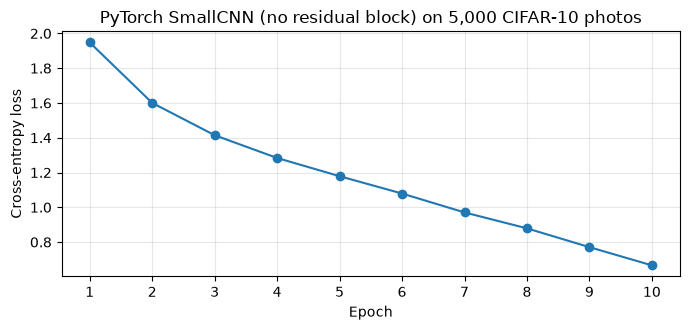

In [5]:
# WHAT: train a small CNN on real CIFAR-10 photos end to end and report test accuracy.
# WHY: real color photos are much harder than MNIST digits - this is the full pipeline on realistic data.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
# Normalize each RGB channel to roughly [-1, 1] so training is stable.
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Two Conv+Pool blocks extract features; Dropout fights overfitting before the final 10-way classifier.
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

# Standard loop: predict, measure loss, backpropagate, update - once per batch, for 10 epochs.
for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

# Evaluation with gradients off: count correct predictions on the held-out test set.
model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

# Whole-numbered epochs, and a title that names WHICH model this curve belongs to.
plt.figure(figsize=(7, 3.4))
plt.plot(range(1, len(losses) + 1), losses, "o-")
plt.title("PyTorch SmallCNN (no residual block) on 5,000 CIFAR-10 photos")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
plt.xticks(range(1, len(losses) + 1)); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read the figure.** This is a **plain** two-block CNN — no residual connection anywhere in it — trained on a 5,000-image CIFAR-10 subset. Loss falls smoothly for all ten epochs and has not flattened, so this run was stopped early rather than finished. It is here as an end-to-end pipeline on real photographs, and it is deliberately **not** evidence about skip connections: at two conv layers there is no depth problem to solve. The evidence about skip connections is the 20-layer measurement in Step 4.

## 💬 Discuss

1. This notebook's objectives openly state that "at this tiny 1-block scale the benefit is not measurable, so we don't pretend to demonstrate it." Is that an admission of failure or good scientific practice? What would a lesson that *did* claim to demonstrate it have to run — and what would it cost?
2. Two numbers appear in this notebook: a mini-ResNet on MNIST, and a plain CNN reaching **60.0%** on CIFAR-10. Which of the two tells you something about *residual connections*, and which tells you something about the *dataset*? Be precise.
3. If skip connections solved the depth problem in 2015, why do teams still ship 16-layer VGG models and 3.5M-parameter MobileNets in 2026? Give two reasons that have nothing to do with accuracy.


## ⚠️ Where this breaks

- **This notebook cannot demonstrate the benefit — and says so in its own objectives.** One residual block, 2 epochs, 5,000 MNIST images is nowhere near the depth at which plain networks degrade. To *see* the effect you would have to build the 20-layer vs 56-layer comparison from the ResNet paper, and that is a GPU-hours experiment, not a notebook cell. Believe the mechanism because of the published curve, not because of anything you just ran.
- **Skip connections do not make depth free.** They fix an optimisation failure. They do nothing about the compute, the memory, or the amount of data needed to fill the extra capacity. A 152-layer ResNet trained on 5,000 images will overfit beautifully, whatever the gradients do.
- **The shape contract bites.** `Add()` requires the block's output and its shortcut to have the same shape, or a projection in between. Getting this wrong usually fails loudly — the good case. The bad case is a 1×1 projection dropped in without thought, which quietly turns the shortcut into another learned layer and removes the thing you added it for.
- **The assumption that must hold:** depth is your bottleneck. Very often it is not. Before adding layers, check whether you are limited by data quantity, label quality, or input resolution — all three are cheaper to fix and more often the real problem.
- **Cheaper alternative:** download a pre-trained ResNet (`06`) instead of building one. You will not out-design He et al. on a Tuesday afternoon, and you should not try.


## 🧩 Mini-exercise

**Try it:** In a new cell, build a second residual block (same pattern: Conv → Conv → Add(shortcut)) and add it to the model, then train for 1 epoch. Compare the number of parameters with the one-block model.

---

## ✅ Summary

**What you did:** Built a small model with a residual block (skip connection) using the Functional API and trained it for 2 epochs on an MNIST subset — a smoke test of the wiring, not a trained model (val accuracy stays low; that is expected). Saw how Add(shortcut) is used.

**Honest note:** with a single residual block this shallow, skip connections give no measurable advantage over a plain stack — their benefit appears at real depth (the ResNet paper trains 50–152 layers).

**In real life you'd also:** Use full ResNet/VGG from Keras Applications, more blocks, and ImageNet pre-training.

**The main idea:** Residual connections (x + F(x)) let gradients flow and allow training deeper CNNs; ResNet-style architectures are standard for image tasks.

**Next:** `05_transfer_learning_cnns` uses pre-trained models; `06_pretrained_cnn_architectures` explores ResNet/VGG/Inception.

## 📚 References

1. He, K., Zhang, X., Ren, S. & Sun, J. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR. https://arxiv.org/abs/1512.03385
2. Simonyan, K. & Zisserman, A. (2015). *Very Deep Convolutional Networks for Large-Scale Image Recognition* (VGG). ICLR. https://arxiv.org/abs/1409.1556
3. Tan, M. & Le, Q. V. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. ICML. https://arxiv.org/abs/1905.11946
4. Liu, Z. et al. (2022). *A ConvNet for the 2020s* (ConvNeXt). CVPR. https://arxiv.org/abs/2201.03545

**Recent work (2024–2026)**

5. Bai et al. (2025). *Qwen3-VL Technical Report*. arXiv. https://arxiv.org/abs/2511.21631 — the current-generation open vision-language model; the architectural centre of gravity in vision moved from deeper CNNs to transformer backbones with longer context.
6. Siméoni, O. et al. (2025). *DINOv3*. arXiv. https://arxiv.org/abs/2508.10104 — and the current open self-supervised vision backbone, if what you want is features rather than language.
